In [1]:
using JLD
using CairoMakie

In [2]:
struct Data
    L::Int
    t::Vector{Float64}
    x::Vector{Float64}
end

In [3]:
set_theme!(
    fontsize=28,
    Legend=(labelsize=28,),
    Axis=(
        xgridvisible=false,
        ygridvisible=false,
    )
)

In [4]:
# ==========================================
# Load data (vN entropy)
# ==========================================

L_list = 6:14

data = Data[]
for L in L_list
    d = load("Ising//random_initial_state//averaged_S_J=1.0_h=0.0_L=$(L).jld")
    t = d["t"]
    x = d["S"] / ((L - 1) * log(2))
    push!(data, Data(L, t, x))
end

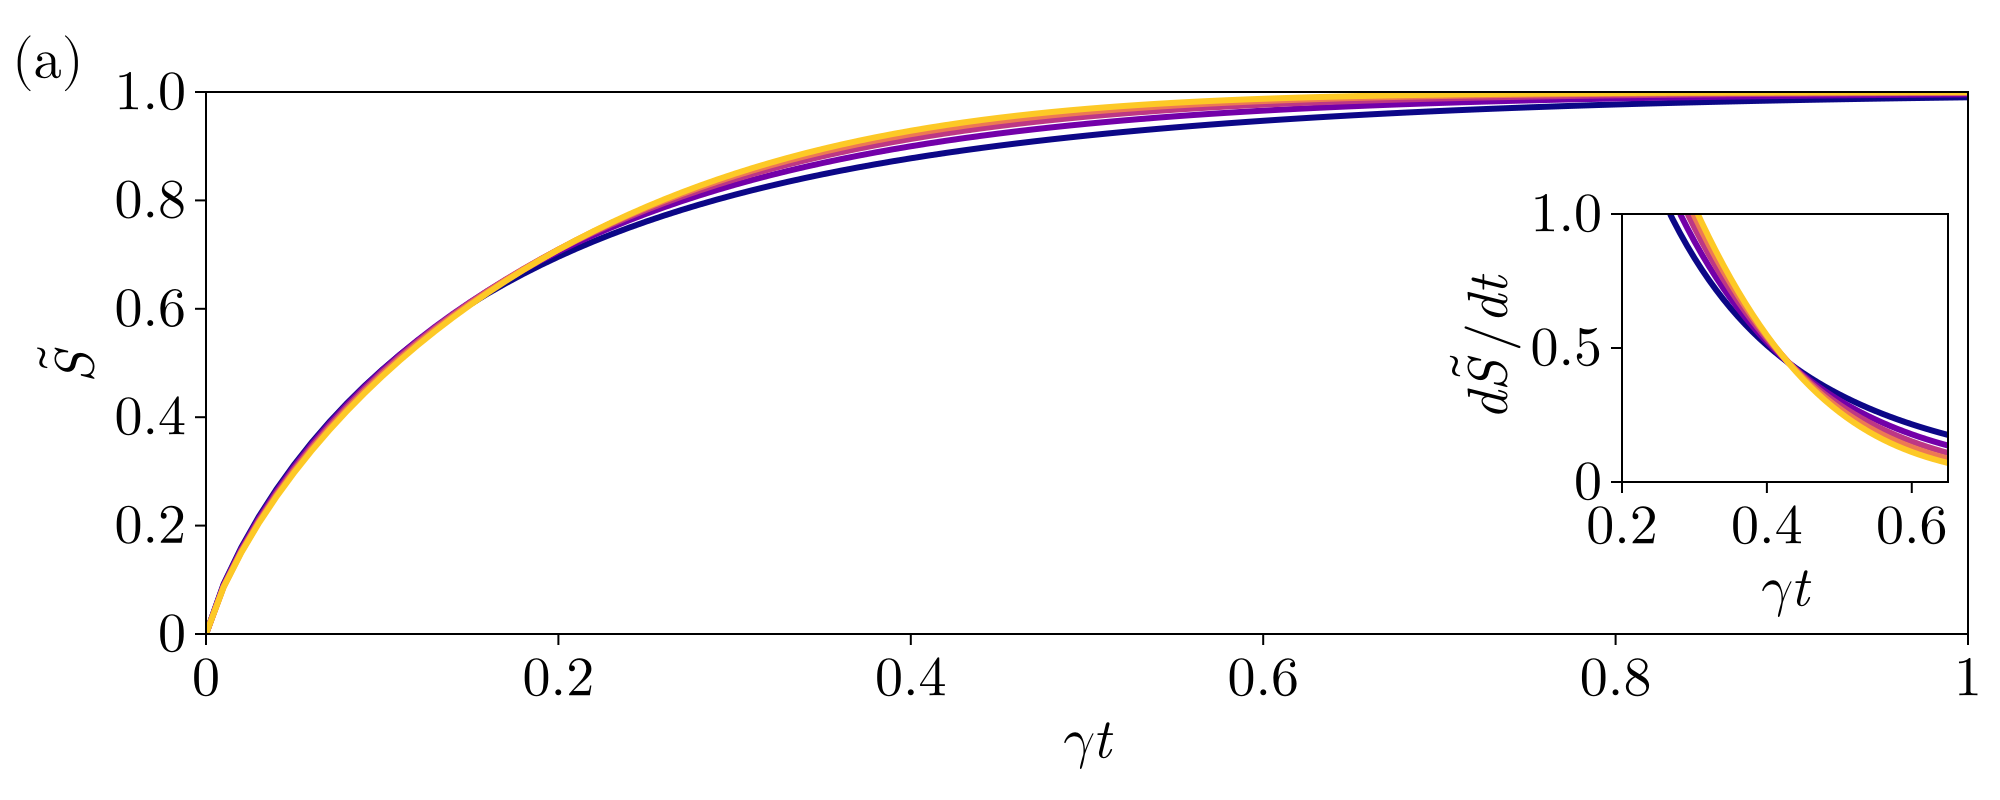

In [5]:
# ==========================================
# Plot vN entropy vs time
# ==========================================

fig = Figure(size=(1000, 400))

ax = Axis(fig[1, 1];
    xticks=(0:0.2:1, [L"0", L"0.2", L"0.4", L"0.6", L"0.8", L"1"]),
    yticks=(0:0.2:1.0, [L"0", L"0.2", L"0.4", L"0.6", L"0.8", L"1.0"]),
    xlabel=L"\gamma t",
    ylabel=L"\tilde{S}")

xlims!(ax, 0, 1)
ylims!(ax, 0, 1)

cmap = cgrad(:plasma)
color_val = [cmap[(i - 1) / (length(data))] for i in 1:length(data)]

label_list = [L"L = 6", L"L = 7", L"L = 8", L"L = 9", L"L = 10", L"L = 11", L"L = 12", L"L = 13", L"L = 14"]

for i in 1:2:9
    lines!(ax, data[i].t, data[i].x, linewidth=3, color = color_val[i], label=label_list[i])
end

# --- Inset: time derivative ---
sub_gl = GridLayout(fig[1, 1], 
    tellwidth = false, 
    tellheight = false, 
    halign = :right, 
    valign = :bottom,
    width = 270,
    height = 220
)

ax_inset = Axis(sub_gl[1, 1],
    xticks=(0.2:0.2:0.6, [L"0.2", L"0.4", L"0.6"]),
    yticks=(0:0.5:1.0, [L"0", L"0.5", L"1.0"]),
    xlabel=L"\gamma t",
    ylabel=L"d\tilde{S}/dt"
)

xlims!(ax_inset, 0.2, 0.65)
ylims!(ax_inset, 0, 01)

for i in 1:2:9
    lines!(ax_inset, data[i].t[1:end-1], (data[i].x[2:end] - data[i].x[1:end-1]) / 0.01, linewidth=3, color = color_val[i], label=label_list[i])
end

sub_gl.alignmode = Outside(10)

Label(fig[1, 1, TopLeft()], L"\mathrm{(a)}";
    fontsize=28,
    halign=:left,
    padding=(-10, 0, 0, 0))

fig

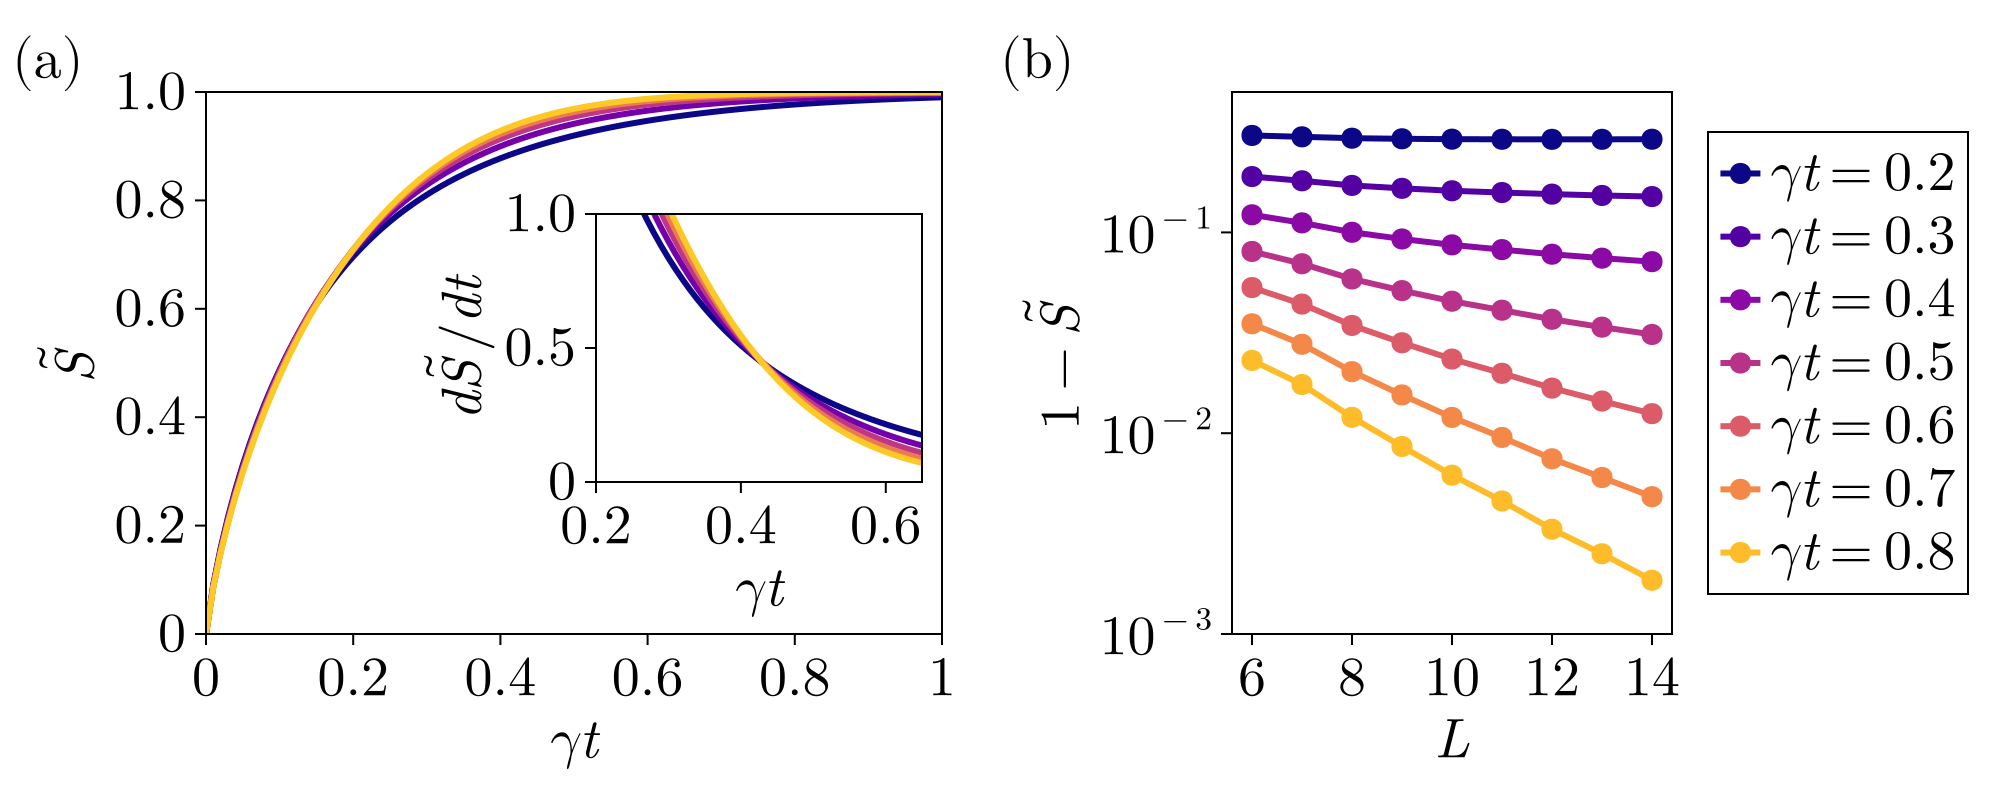

In [6]:
# ==========================================
# Plot vN entropy vs system size
# ==========================================

t_targets = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

ax = Axis(fig[1, 2][1, 1];
    xticks=(6:2:14, [L"%$L" for L in 6:2:14]),
    yticks=([1e-3, 1e-2, 1e-1, 1], [L"10^{-3}", L"10^{-2}", L"10^{-1}", L"1"]),
    xlabel=L"L",
    ylabel=L"1 - \tilde{S}",
    yscale=log10)

ylims!(ax, 1e-3, 0.5)

cmap = cgrad(:plasma)
color_val = [cmap[(i - 1) / (length(t_targets))] for i in 1:length(t_targets)]

for (i, t_target) in enumerate(t_targets)
    L_vals = Int[]
    x_vals = Float64[]
    
    for d in data
        idx = argmin(abs.(d.t .- t_target))
        
        push!(L_vals, d.L)
        push!(x_vals, d.x[idx])
    end
    
    scatterlines!(ax, L_vals, 1 .- x_vals;
        linewidth=3,
        markersize=15,
        color=color_val[i],
        label=L"\gamma t = %$(t_target)")
end

Legend(fig[1, 2][1, 2], ax)

Label(fig[1, 2, TopLeft()], L"\mathrm{(b)}";
    fontsize=28,
    halign=:left,
    padding=(-10, 0, 0, 0))

colgap!(fig.layout, 1, Relative(0.05))

fig